## 1. Imports & Konfiguration

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("TensorFlow Version:", tf.__version__)
print("GPU verfügbar:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.21.0
GPU verfügbar: []


In [4]:
# ── Konfiguration ──────────────────────────────────────────────────────────────
DATA_DIR   = Path("../../data/Apple_Data_bereinigt")
IMG_SIZE   = (224, 224)   
BATCH_SIZE = 32
SEED       = 42

# Trainingsparameter
EPOCHS_TRANSFER  = 5   # Phase 1: nur Dense-Head trainieren
EPOCHS_FINETUNE  = 3   # Phase 2: obere Schichten fine-tunen
LR_TRANSFER      = 1e-3
LR_FINETUNE      = 1e-5  # sehr klein für Fine-Tuning!
FINETUNE_FROM    = 100   # ab diesem Layer auftauen (von ~154 gesamt)

MODEL_PATHo = Path("../../modelle/final/MobileNetV2ohneFT.keras")
MODEL_PATHft = Path("../../modelle/final/MobileNetV2FT.keras")
MODEL_PATHo.parent.mkdir(parents=True, exist_ok=True)
MODEL_PATHft.parent.mkdir(parents=True, exist_ok=True)

## 2. Dataset laden & aufteilen (70/15/15)

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

# Temp-Split in Val und Test aufteilen
temp_batches = temp_ds.cardinality().numpy()
val_batches  = temp_batches // 2
val_ds   = temp_ds.take(val_batches)
test_ds  = temp_ds.skip(val_batches)

print("Klassen:",             class_names)
print("Training Batches:",    train_ds.cardinality().numpy())
print("Validation Batches:",  val_ds.cardinality().numpy())
print("Test Batches:",        test_ds.cardinality().numpy())

Found 4751 files belonging to 2 classes.
Using 3326 files for training.
Found 4751 files belonging to 2 classes.
Using 1425 files for validation.
Klassen: ['Apple__Healthy', 'Apple__Rotten']
Training Batches: 104
Validation Batches: 22
Test Batches: 23


## 3. Data Augmentation

Besonders wichtig für Agrardaten: Bilder entstehen unter wechselnden
Lichtverhältnissen, Kamerawinkeln und Abständen.

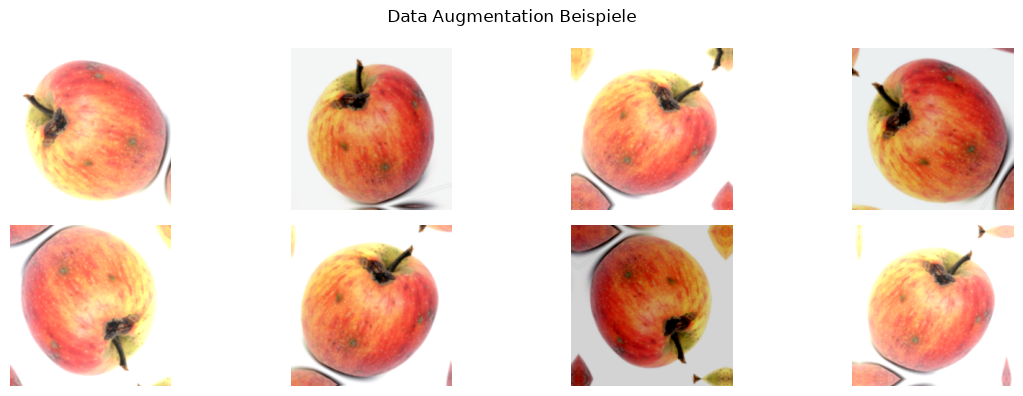

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.1),
], name="augmentation")

# Augmentation-Vorschau
sample_images, _ = next(iter(train_ds))
plt.figure(figsize=(12, 4))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    aug_img = data_augmentation(tf.expand_dims(sample_images[0], 0), training=True)
    plt.imshow(aug_img[0].numpy().astype("uint8"))
    plt.axis("off")
plt.suptitle("Data Augmentation Beispiele")
plt.tight_layout()
plt.show()

## 4. Performance-Optimierung des Datenpipeline

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

# Nur Training erhält Augmentation — Val/Test niemals!
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_ds  = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

## 5. Modell aufbauen

**Phase 1:** MobileNetV2 eingefroren, nur Dense-Head trainieren  
**Phase 2:** Obere Schichten auftauen und mit sehr kleiner LR fine-tunen

In [8]:
def build_model(num_classes, finetune=False, finetune_from=100):
    """Baut das MobileNetV2-Modell.
    finetune=False  → alle Base-Schichten eingefroren
    finetune=True   → Schichten ab finetune_from auftauen
    """
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    if finetune:
        base_model.trainable = True
        for layer in base_model.layers[:finetune_from]:
            layer.trainable = False
        print(f"Fine-Tuning: {sum(l.trainable for l in base_model.layers)} "
              f"von {len(base_model.layers)} Schichten trainierbar")
    else:
        base_model.trainable = False
        print("Transfer Learning: Base Model eingefroren")

    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        layers.Rescaling(scale=1./127.5, offset=-1.0, name="mobilenet_preprocess"),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ], name="MobileNetV2_Agrarkontrolle")

    return model, base_model

model, base_model = build_model(num_classes)
model.summary()

Transfer Learning: Base Model eingefroren


Model: "MobileNetV2_Agrarkontrolle"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_preprocess            │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,591,554 (9.89 MB)

 Trainable params: 331,010 (1.26 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 6. Phase 1 – Transfer Learning (Base eingefroren)

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_TRANSFER),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_phase1 = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_PATHo,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

print("=== Phase 1: Transfer Learning ===")
history_transfer = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_TRANSFER,
    callbacks=callbacks_phase1
)

=== Phase 1: Transfer Learning ===
Epoch 1/5


c:\Users\benke\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9799 - loss: 0.0728
Epoch 1: val_loss improved from None to 0.08713, saving model to ..\..\modelle\final\MobileNetV2ohneFT.keras

Epoch 1: finished saving model to ..\..\modelle\final\MobileNetV2ohneFT.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9799 - loss: 0.0728 - val_accuracy: 0.9773 - val_loss: 0.0871 - learning_rate: 0.0010
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9844 - loss: 0.0454
Epoch 2: val_loss improved from 0.08713 to 0.06994, saving model to ..\..\modelle\final\MobileNetV2ohneFT.keras

Epoch 2: finished saving model to ..\..\modelle\final\MobileNetV2ohneFT.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9844 - loss: 0.0454 - val_accuracy: 0.9858 - val_loss: 0.0699 - learning_rate: 0.0010
Epoch 3/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9859 - loss: 0.0429
Epoch 3: val_loss did not improve from 0.06994
104/104 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accu

## 7. Phase 2 – Fine-Tuning (obere Schichten auftauen)

In [11]:
# Obere Schichten des Base Models auftauen
base_model.trainable = True
for layer in base_model.layers[:FINETUNE_FROM]:
    layer.trainable = False

trainable_count = sum(l.trainable for l in base_model.layers)
print(f"Fine-Tuning: {trainable_count} von {len(base_model.layers)} Base-Schichten trainierbar")

# Sehr kleine Learning Rate für Fine-Tuning!
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_FINETUNE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_phase2 = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_PATHft,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("=== Phase 2: Fine-Tuning ===")
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINETUNE,
    callbacks=callbacks_phase2
)

Fine-Tuning: 54 von 154 Base-Schichten trainierbar
=== Phase 2: Fine-Tuning ===
Epoch 1/3
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9357 - loss: 0.2454
Epoch 1: val_loss improved from None to 0.17240, saving model to ..\..\modelle\final\MobileNetV2FT.keras

Epoch 1: finished saving model to ..\..\modelle\final\MobileNetV2FT.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 299s 2s/step - accuracy: 0.9357 - loss: 0.2454 - val_accuracy: 0.9659 - val_loss: 0.1724
Epoch 2/3
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9657 - loss: 0.1320
Epoch 2: val_loss did not improve from 0.17240
104/104 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.9657 - loss: 0.1320 - val_accuracy: 0.9645 - val_loss: 0.1729
Epoch 3/3
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9729 - loss: 0.1029
Epoch 3: val_loss improved from 0.17240 to 0.13254, saving model to ..\..\modelle\final\MobileNetV2FT.keras

Epoch 3: finished saving model to ..\..\modelle\final\MobileNetV2FT.keras
104/104 ━━━━━━━━━━━━━━

## 8. Trainingsverläufe visualisieren

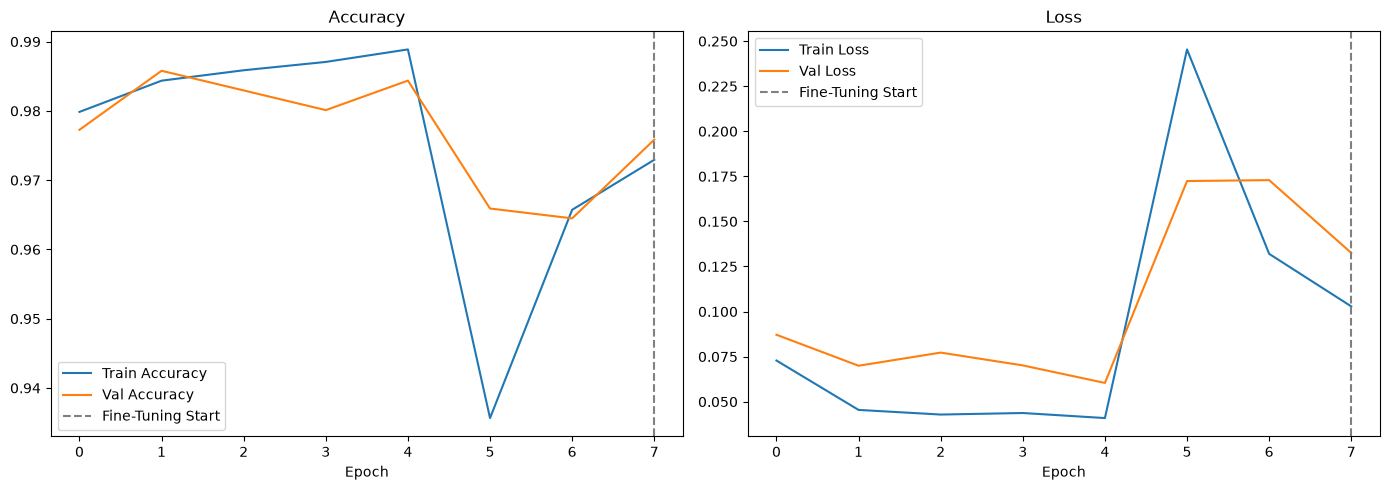

In [12]:
def plot_history(h1, h2=None):
    """Zeigt Accuracy und Loss beider Trainingsphasen."""
    acc  = h1.history["accuracy"]
    val_acc  = h1.history["val_accuracy"]
    loss = h1.history["loss"]
    val_loss = h1.history["val_loss"]

    if h2:
        acc      += h2.history["accuracy"]
        val_acc  += h2.history["val_accuracy"]
        loss     += h2.history["loss"]
        val_loss += h2.history["val_loss"]
        split_at = len(h1.history["accuracy"])
    else:
        split_at = None

    epochs_range = range(len(acc))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs_range, acc, label="Train Accuracy")
    ax1.plot(epochs_range, val_acc, label="Val Accuracy")
    if split_at:
        ax1.axvline(split_at - 1, color="gray", linestyle="--", label="Fine-Tuning Start")
    ax1.set_title("Accuracy"); ax1.legend(); ax1.set_xlabel("Epoch")

    ax2.plot(epochs_range, loss, label="Train Loss")
    ax2.plot(epochs_range, val_loss, label="Val Loss")
    if split_at:
        ax2.axvline(split_at - 1, color="gray", linestyle="--", label="Fine-Tuning Start")
    ax2.set_title("Loss"); ax2.legend(); ax2.set_xlabel("Epoch")

    plt.tight_layout()
    plt.savefig("training_history.png", dpi=150)
    plt.show()

plot_history(history_transfer, history_finetune)

## 9. Evaluation auf dem Test-Set

In [14]:
# Bestes Modell laden
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

model = tf.keras.models.load_model(
    MODEL_PATHft,
    custom_objects={"preprocess_input": preprocess_input}
)

print("=== Test-Set Evaluation ===")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

=== Test-Set Evaluation ===
23/23 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9889 - loss: 0.0577
Test Accuracy: 0.9889
Test Loss:     0.0577


## 10. Confusion Matrix & Classification Report

                precision    recall  f1-score   support

Apple__Healthy     0.9720    1.0000    0.9858       278
 Apple__Rotten     1.0000    0.9819    0.9909       443

      accuracy                         0.9889       721
     macro avg     0.9860    0.9910    0.9884       721
  weighted avg     0.9892    0.9889    0.9889       721



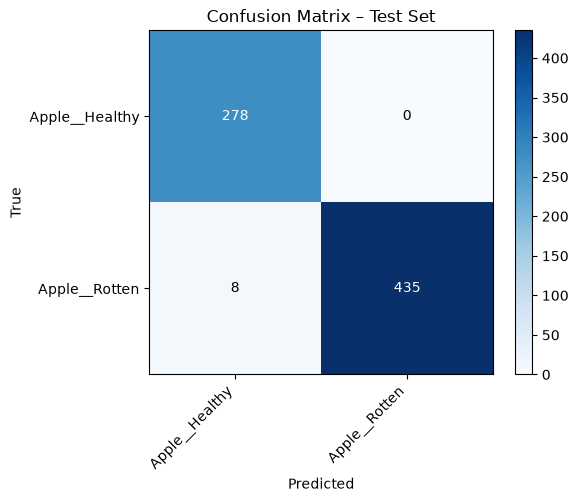

In [15]:
y_true, y_pred = [], []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion Matrix visualisieren
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im)
ax.set_xticks(range(num_classes)); ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(num_classes)); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix – Test Set")
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## 11. Falsch klassifizierte Bilder analysieren

Falsch klassifiziert: 21 Bilder


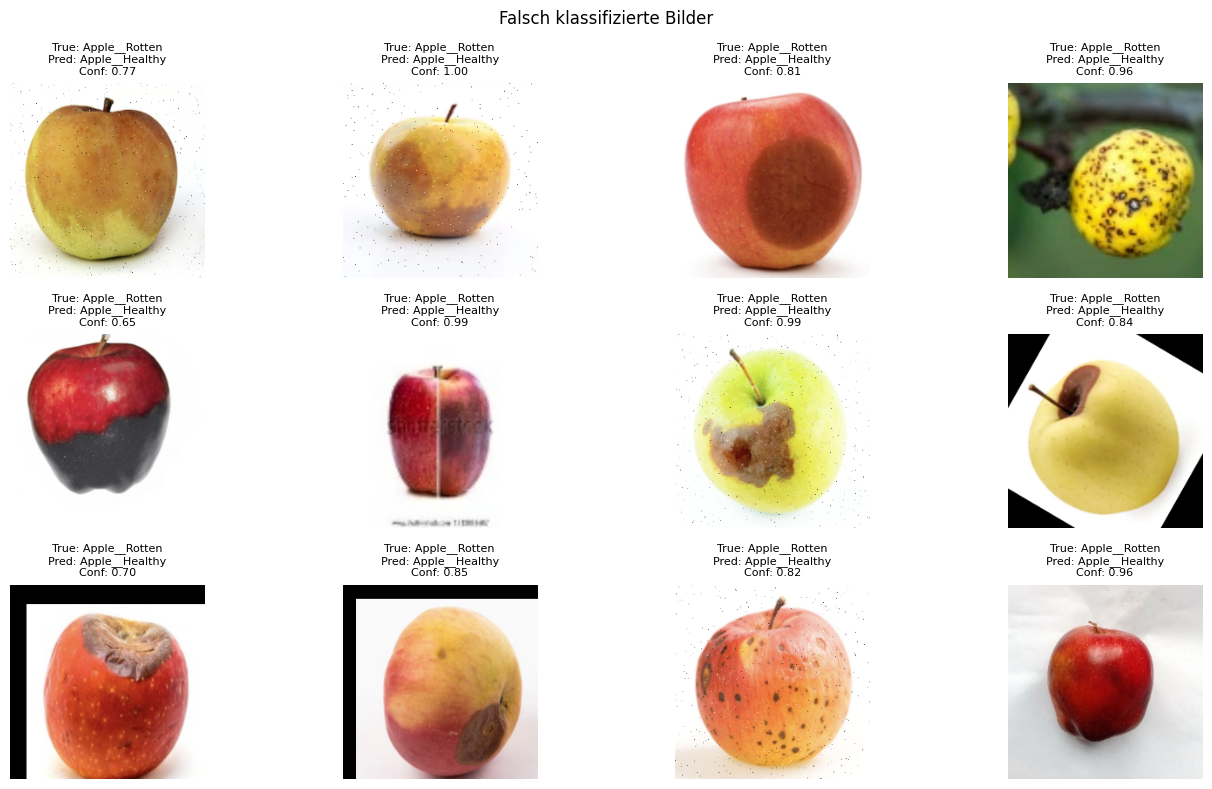

In [28]:
wrong_images, wrong_true, wrong_pred, wrong_conf = [], [], [], []

for images, labels in test_ds:
    preds       = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    confidences = np.max(preds, axis=1)

    for i in range(len(labels)):
        t = int(labels[i].numpy())
        p = int(pred_labels[i])
        if t != p:
            wrong_images.append(images[i].numpy().astype("uint8"))
            wrong_true.append(t)
            wrong_pred.append(p)
            wrong_conf.append(float(confidences[i]))

print(f"Falsch klassifiziert: {len(wrong_images)} Bilder")

n = min(12, len(wrong_images))
if n > 0:
    plt.figure(figsize=(14, 8))
    for i in range(n):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(wrong_images[i])
        plt.title(
            f"True: {class_names[wrong_true[i]]}\n"
            f"Pred: {class_names[wrong_pred[i]]}\n"
            f"Conf: {wrong_conf[i]:.2f}",
            fontsize=8
        )
        plt.axis("off")
    plt.suptitle("Falsch klassifizierte Bilder", fontsize=12)
    plt.tight_layout()
    plt.savefig("wrong_predictions.png", dpi=150)
    plt.show()
else:
    print("Keine Fehler gefunden – perfekte Klassifikation auf dem Test-Set!")